In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip '/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8.zip' -d '/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8'

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan33_jpg.rf.3202b6f9697f43ab0f809e185223fe71.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan341_jpg.rf.246f8355aa731fd0715bb1af11652233.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan342_jpg.rf.4f357238ff6dbf3a52d9c81ff979c1d5.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan343_jpg.rf.1eb3399a87fdc3e151b9763d6049f964.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan344_jpg.rf.c8adab6d84569544483363a24f90666e.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan345_jpg.rf.4b5546781ec56ce672692c5a73c04d18.txt  
  inflating: /content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train/labels/AluCan346_jpg.rf.4a

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd

In [5]:
dataset_path = '/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/train'
image_path = os.path.join(dataset_path, 'images')
label_path = os.path.join(dataset_path, 'labels')

# Get list of image files
image_files = [os.path.join(image_path, file) for file in os.listdir(image_path) if file.endswith('.jpg')]
class_names = ['Glass_bottles','Aluminium_Cans','PET_(plastic)_bottles','HDPE_(plastic)_Milk bottles']

class_dict_names = {i: name for i, name in enumerate(class_names)}
colors = [(255, 0, 0), (0, 255, 0), (0, 0, 255)]  # Different colors for each class
colors_normalized = [(r / 255, g / 255, b / 255) for (r, g, b) in colors]

In [6]:
class_dict_names

{0: 'Glass_bottles',
 1: 'Aluminium_Cans',
 2: 'PET_(plastic)_bottles',
 3: 'HDPE_(plastic)_Milk bottles'}

Number of training images: 3322
Number of validation images: 949
Number of test images: 475


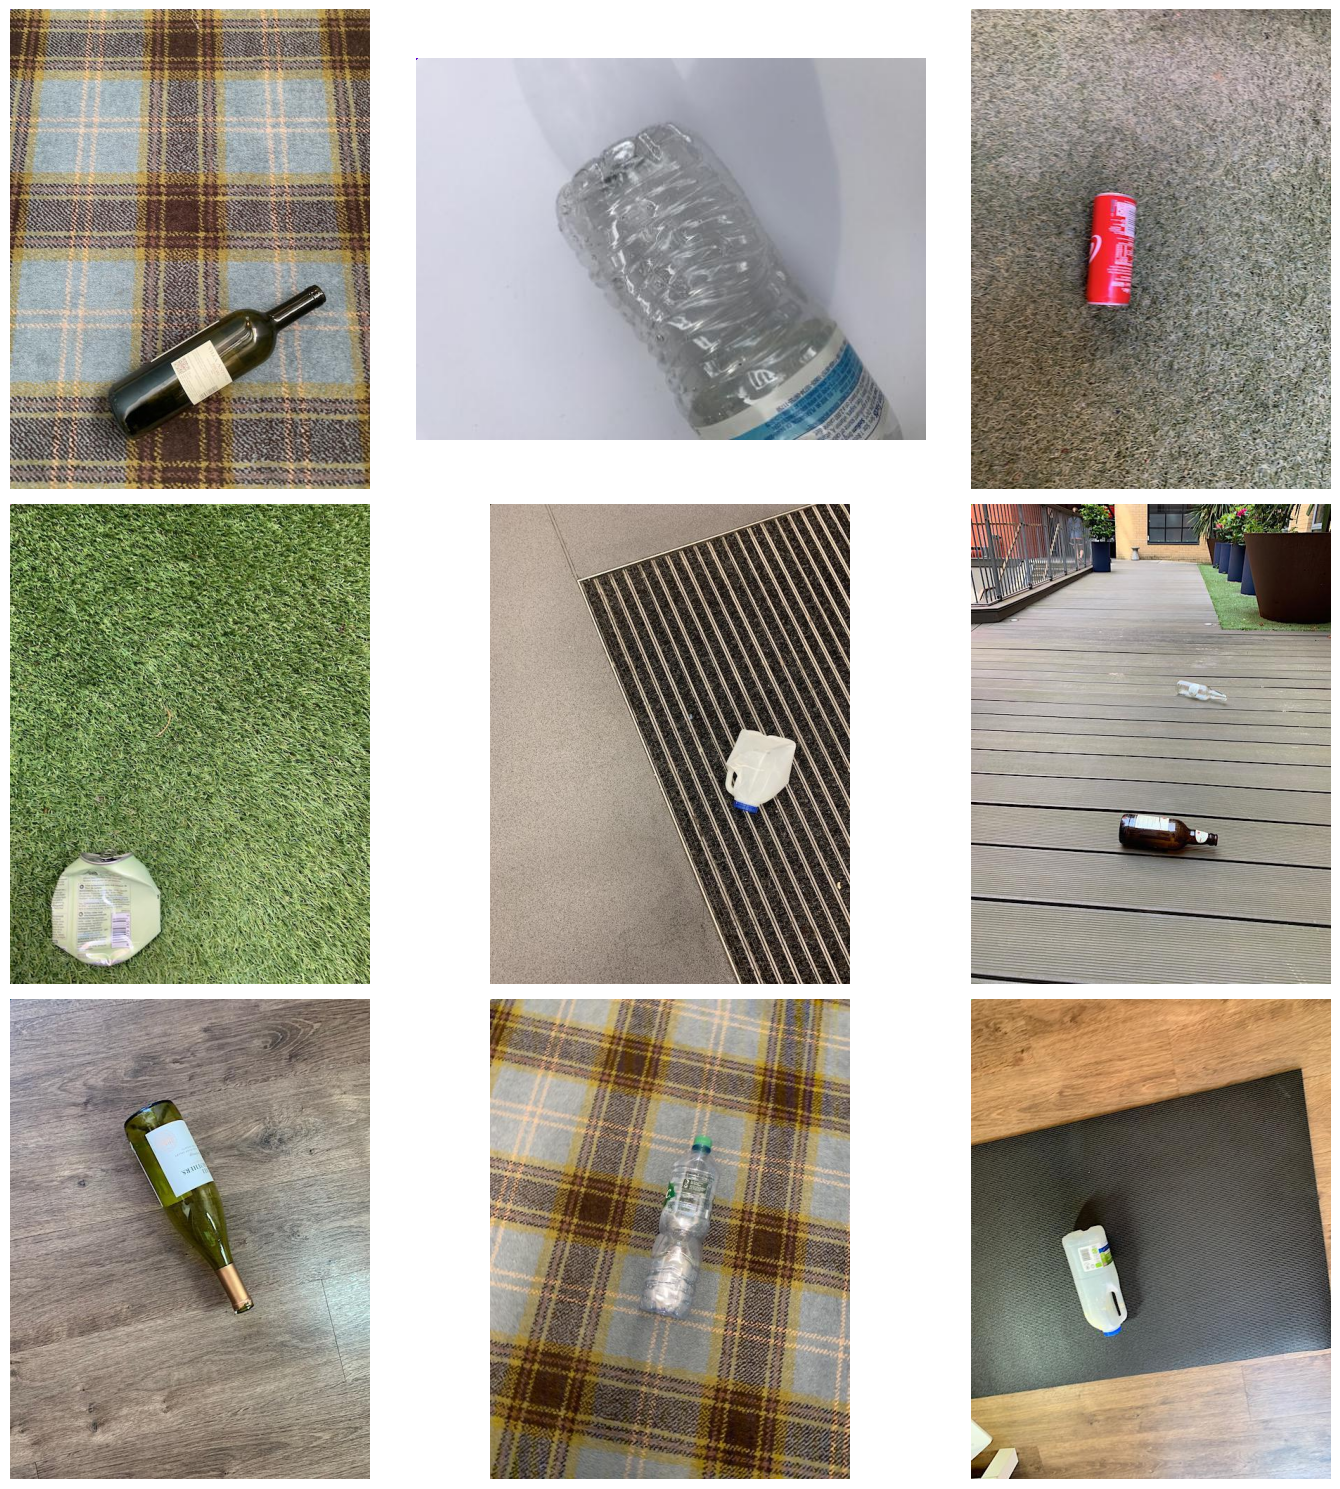

Total images per class: {1: 777, 0: 1029, 3: 734, 2: 993}


In [7]:
import os
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np

# Define paths
base_path = '/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8'
train_images_path = os.path.join(base_path, 'train', 'images')
train_labels_path = os.path.join(base_path, 'train', 'labels')
val_images_path = os.path.join(base_path, 'valid', 'images')
test_images_path = os.path.join(base_path, 'test', 'images')

# Function to count files
def count_files(directory):
    return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])

# Displaying counts for train, val, and test directories
train_count = count_files(train_images_path)
val_count = count_files(val_images_path)
test_count = count_files(test_images_path)
print("Number of training images:", train_count)
print("Number of validation images:", val_count)
print("Number of test images:", test_count)

# Function to display images with segmented colors and labels
def display_segmented_images(image_folder, label_folder, num_images=9):
    image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.endswith('.jpg')]
    sampled_images = random.sample(image_files, min(len(image_files), num_images))

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    axs = axs.flatten()

    for ax, img_path in zip(axs, sampled_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label_file = os.path.join(label_folder, os.path.basename(img_path).replace('.jpg', '.txt'))
        with open(label_file, 'r') as file:
            data = file.readlines()
            for line in data:
                elements = line.split()
                class_id = int(elements[0])
                coordinates = list(map(float, elements[1:]))
                polygon = np.array([[(x, y) for x, y in zip(coordinates[0::2], coordinates[1::2])]], dtype=np.int32)
                cv2.polylines(img, [polygon], isClosed=True, color=np.random.randint(0, 255, size=3).tolist(), thickness=2)

        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display images
display_segmented_images(train_images_path, train_labels_path)

# Function to calculate total images for each class across all datasets
def total_images_for_each_class(image_folder, label_folder):
    class_counts = {}
    label_files = [os.path.join(label_folder, file) for file in os.listdir(label_folder) if file.endswith('.txt')]
    for label_file in label_files:
        with open(label_file, 'r') as file:
            data = file.readlines()
            for line in data:
                class_id = int(line.split()[0])
                class_counts[class_id] = class_counts.get(class_id, 0) + 1
    return class_counts

# Calculate and display the total number of images for each class
class_counts = total_images_for_each_class(train_images_path, train_labels_path)
print("Total images per class:", class_counts)


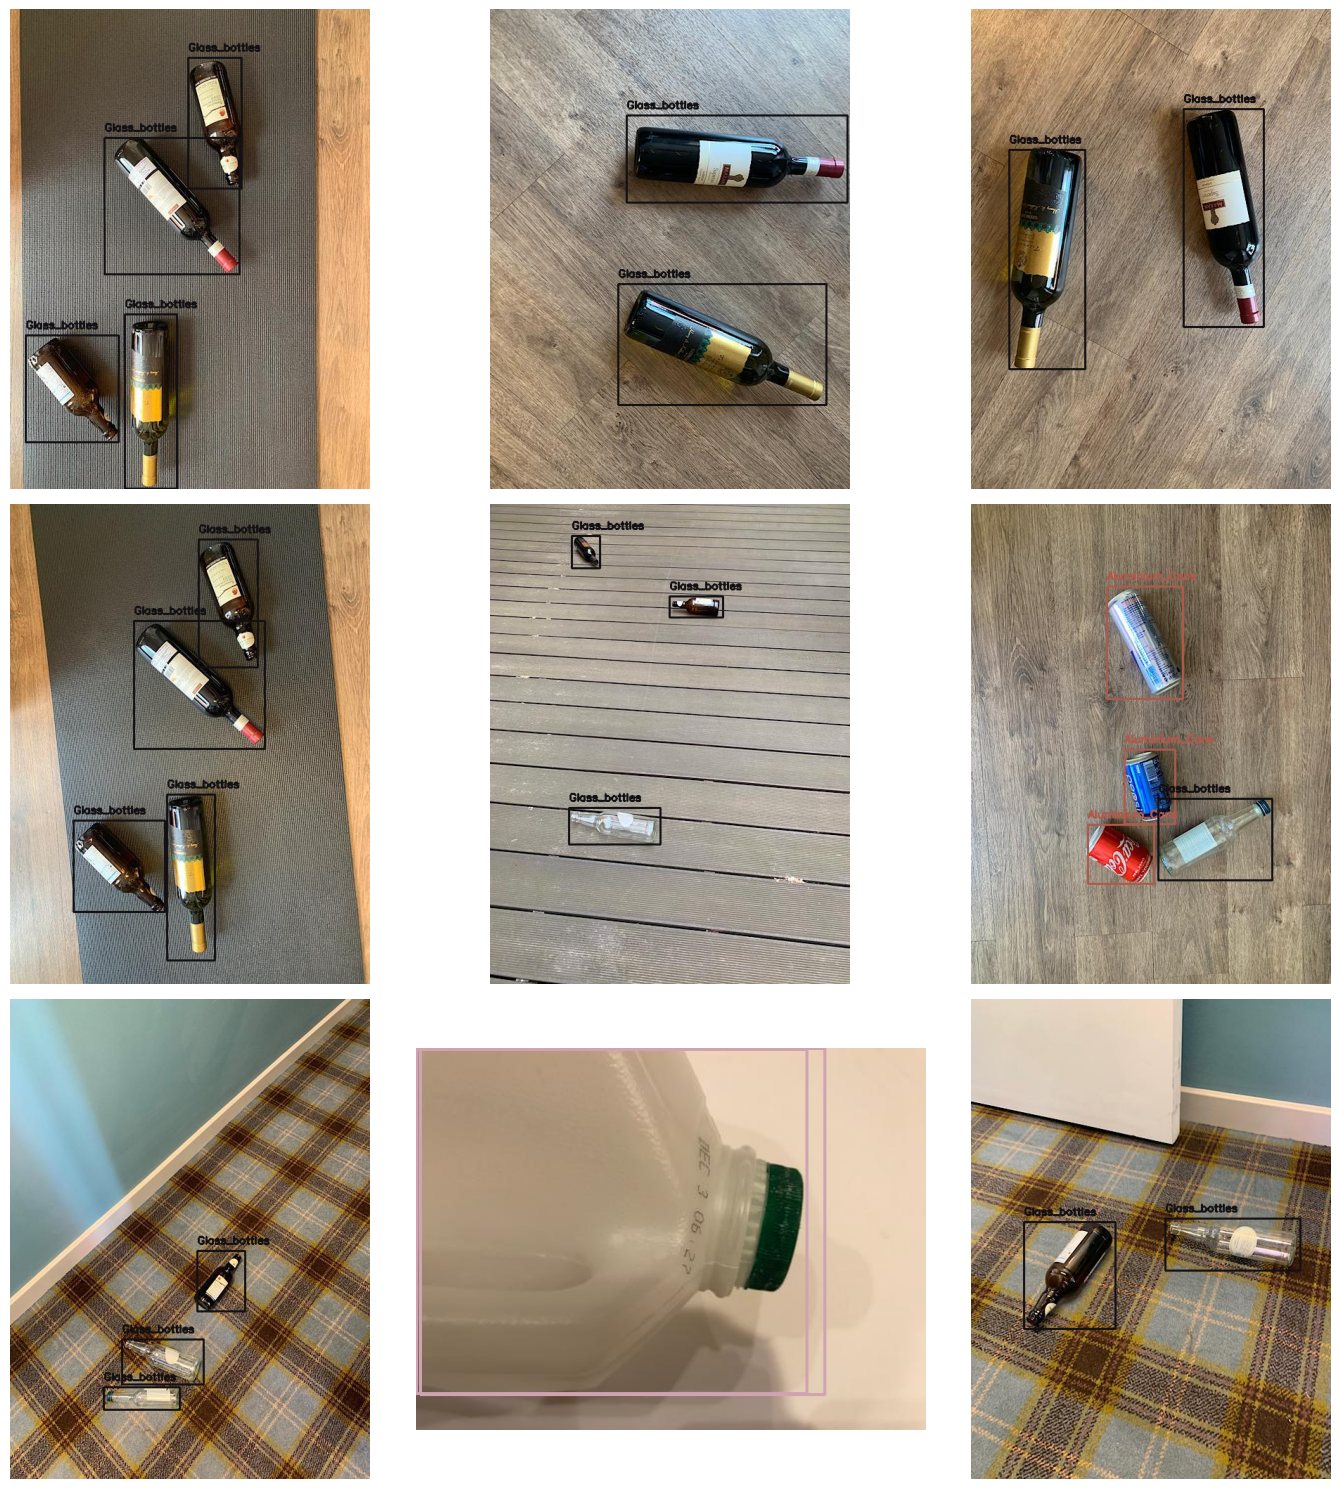

In [9]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np

# Define paths
base_path = '/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8'
train_path = os.path.join(base_path, 'train')
val_path = os.path.join(base_path, 'valid')
test_path = os.path.join(base_path, 'test')

image_path = os.path.join(train_path, 'images')
label_path = os.path.join(train_path, 'labels')

# Get list of image files
image_files = [os.path.join(image_path, file) for file in os.listdir(image_path) if file.endswith('.jpg')]

# Define class names and generate colors
class_names = ['Glass_bottles','Aluminium_Cans','PET_(plastic)_bottles','HDPE_(plastic)_Milk bottles']
colors = [tuple(int(x * 255) for x in np.random.rand(3)) for _ in range(len(class_names))] # Use red color for all classes# Generate random colors for each class

def display_images(image_files, num_images=9):
    valid_image_files = []

    for img_path in image_files:
        txt_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        with open(txt_path, 'r') as f:
            lines = f.readlines()
            if len(lines) > 1:  # Only consider images with more than one label
                valid_image_files.append(img_path)

    if not valid_image_files:
        print("No images found with more than one label.")
        return

    selected_images = random.sample(valid_image_files, min(num_images, len(valid_image_files)))

    fig, axs = plt.subplots(3, 3, figsize=(15, 15))
    for i, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        txt_path = img_path.replace('images', 'labels').replace('.jpg', '.txt')
        with open(txt_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                class_id = int(parts[0])
                cx, cy, w, h = [float(x) for x in parts[1:]]

                # Convert normalized center coordinates to pixel coordinates
                cx = int(cx * img.shape[1])
                cy = int(cy * img.shape[0])
                w = int(w * img.shape[1])
                h = int(h * img.shape[0])

                # Calculate the top-left and bottom-right corners
                x1 = cx - w // 2
                y1 = cy - h // 2
                x2 = cx + w // 2
                y2 = cy + h // 2

                # Draw the bounding box
                cv2.rectangle(img, (x1, y1), (x2, y2), colors[class_id], 2)
                cv2.putText(img, class_names[class_id], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[class_id], 2)

        ax = axs[i // 3, i % 3]
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('3.png')
    plt.show()

display_images(image_files)


In [10]:
def count_images(directory):
    return len([name for name in os.listdir(os.path.join(directory, 'images')) if name.endswith('.jpg')])

train_count = count_images(train_path)
val_count = count_images(val_path)
test_count = count_images(test_path)
print("********** Trash Dataset of 22 classes ***************")
print(f"Number of images in Train: {train_count}")
print(f"Number of images in Validation: {val_count}")
print(f"Number of images in Test: {test_count}")

********** Trash Dataset of 22 classes ***************
Number of images in Train: 3322
Number of images in Validation: 949
Number of images in Test: 475


In [11]:
from collections import defaultdict

def count_classes_across_datasets(base_path, class_names):
    counts = defaultdict(int)
    for phase in ['train', 'valid', 'test']:
        label_dir = os.path.join(base_path, phase, 'labels')
        for label_file in os.listdir(label_dir):
            with open(os.path.join(label_dir, label_file), 'r') as f:
                for line in f:
                    class_id = int(line.strip().split()[0])
                    counts[class_names[class_id]] += 1
    return dict(counts)

class_counts = count_classes_across_datasets(base_path, class_names)
print("Image count per class across all datasets:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


Image count per class across all datasets:
Aluminium_Cans: 1128
Glass_bottles: 1419
HDPE_(plastic)_Milk bottles: 1027
PET_(plastic)_bottles: 1426


<ipython-input-12-ed6bde4f463a>:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('hsv', len(class_names))


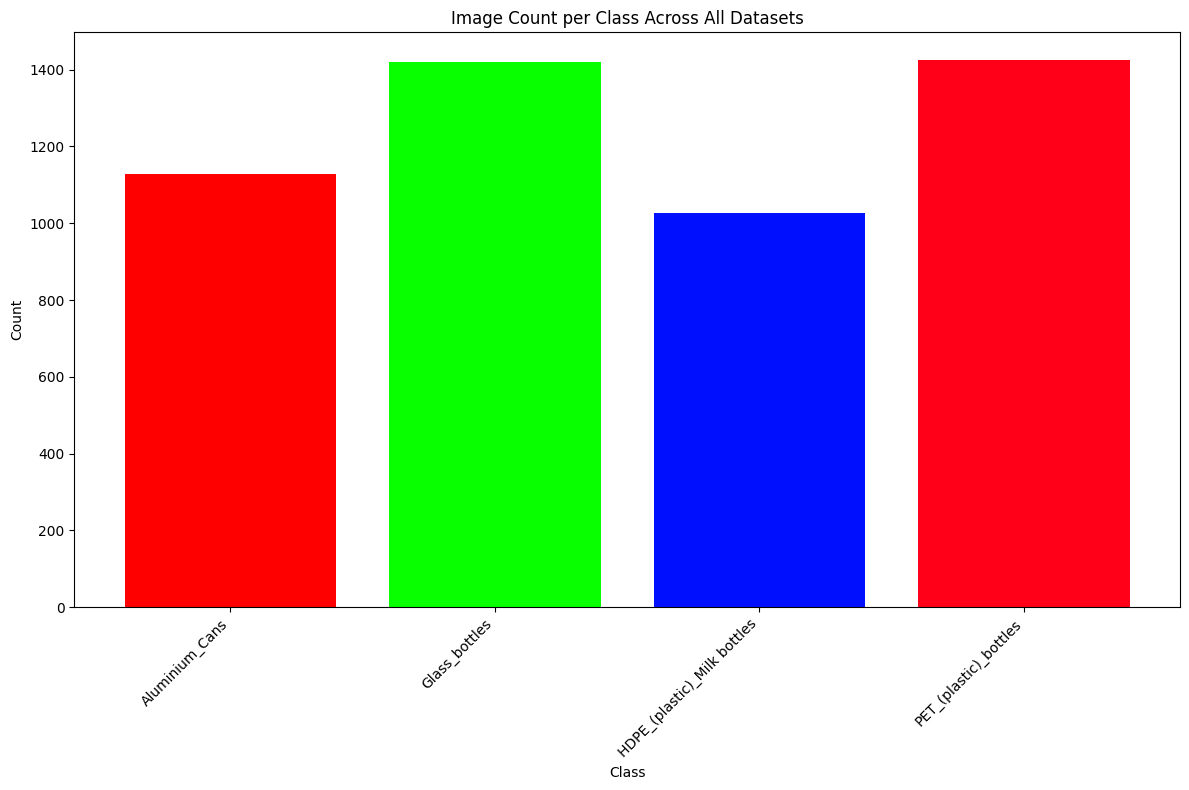

In [12]:
colors = plt.cm.get_cmap('hsv', len(class_names))

# Create the bar plot
plt.figure(figsize=(12, 8))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=[colors(i) for i in range(len(class_counts))])

# Add labels and title
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Image Count per Class Across All Datasets')
plt.xticks(rotation=45, ha='right')  # Rotate class names for better readability

# Show the plot
plt.tight_layout()
plt.savefig('trash_can_dataset_dist_22.png')
plt.show()

In [13]:
!pip install ultralytics==8.0.28

from IPython import display
display.clear_output()


import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.28 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 34.4/78.2 GB disk)


In [15]:
!yolo detect train model=yolov8x.pt data="/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/data.yaml" epochs=10 imgsz=640 save=true batch=8


100% 131M/131M [00:00<00:00, 333MB/s]
Ultralytics YOLOv8.0.28 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
yolo/engine/trainer: task=detect, mode=train, model=yolov8x.pt, data=/content/drive/MyDrive/Drinking_Waste_Detection.v1i.yolov8/data.yaml, epochs=10, patience=50, batch=8, imgsz=640, save=True, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=False, optimizer=SGD, verbose=True, seed=0, deterministic=True, single_cls=False, image_weights=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, hide_labels=False, hide_conf=False, vid_stride=1, line_thickness=3, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, boxes=True, format=torchscript, keras=False

In [16]:
!zip -r /content/drive/MyDrive/runs_Drinking_Waste_Detection.v1i.yolov8.zip /content/runs

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 3%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 6%)
  adding: content/runs/detect/train/PR_curve.png (deflated 13%)
  adding: content/runs/detect/train/results.csv (deflated 82%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 10%)
  adding: content/runs/detect/train/R_curve.png (deflated 10%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/last.pt (deflated 8%)
  adding: content/runs/detect/train/weights/best.pt (deflated 8%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 14%)
  adding: content/runs/detect/train/val_batch0_labels.jpg (deflated 14%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 13%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 23%)
  